MALAYSIA HOUSING PRICE PREDICTION - COMPLETE ML PROJECT

PHASE 1: EXPLORATORY DATA ANALYSIS (EDA)

✓ Dataset loaded: 2,847 records, 13 features

[1.1] DATASET OVERVIEW
----------------------------------------------------------------------------------------------------
Shape: (2847, 13)

First 10 rows:
   location property_type  bedrooms  bathrooms  built_up_area  year_built  \
0     Johor      Bungalow         3          1           2648        2024   
1     Sabah      Bungalow         3          3           3184        2018   
2    Penang         Condo         1          2           2822        2007   
3     Sabah         Condo         1          2           4541        2001   
4     Sabah       Terrace         2          4           2098        2008   
5  Selangor         Condo         5          1           4902        2011   
6    Penang       Terrace         5          4           1704        2004   
7    Penang      Bungalow         5          1           3826        1990   
8   

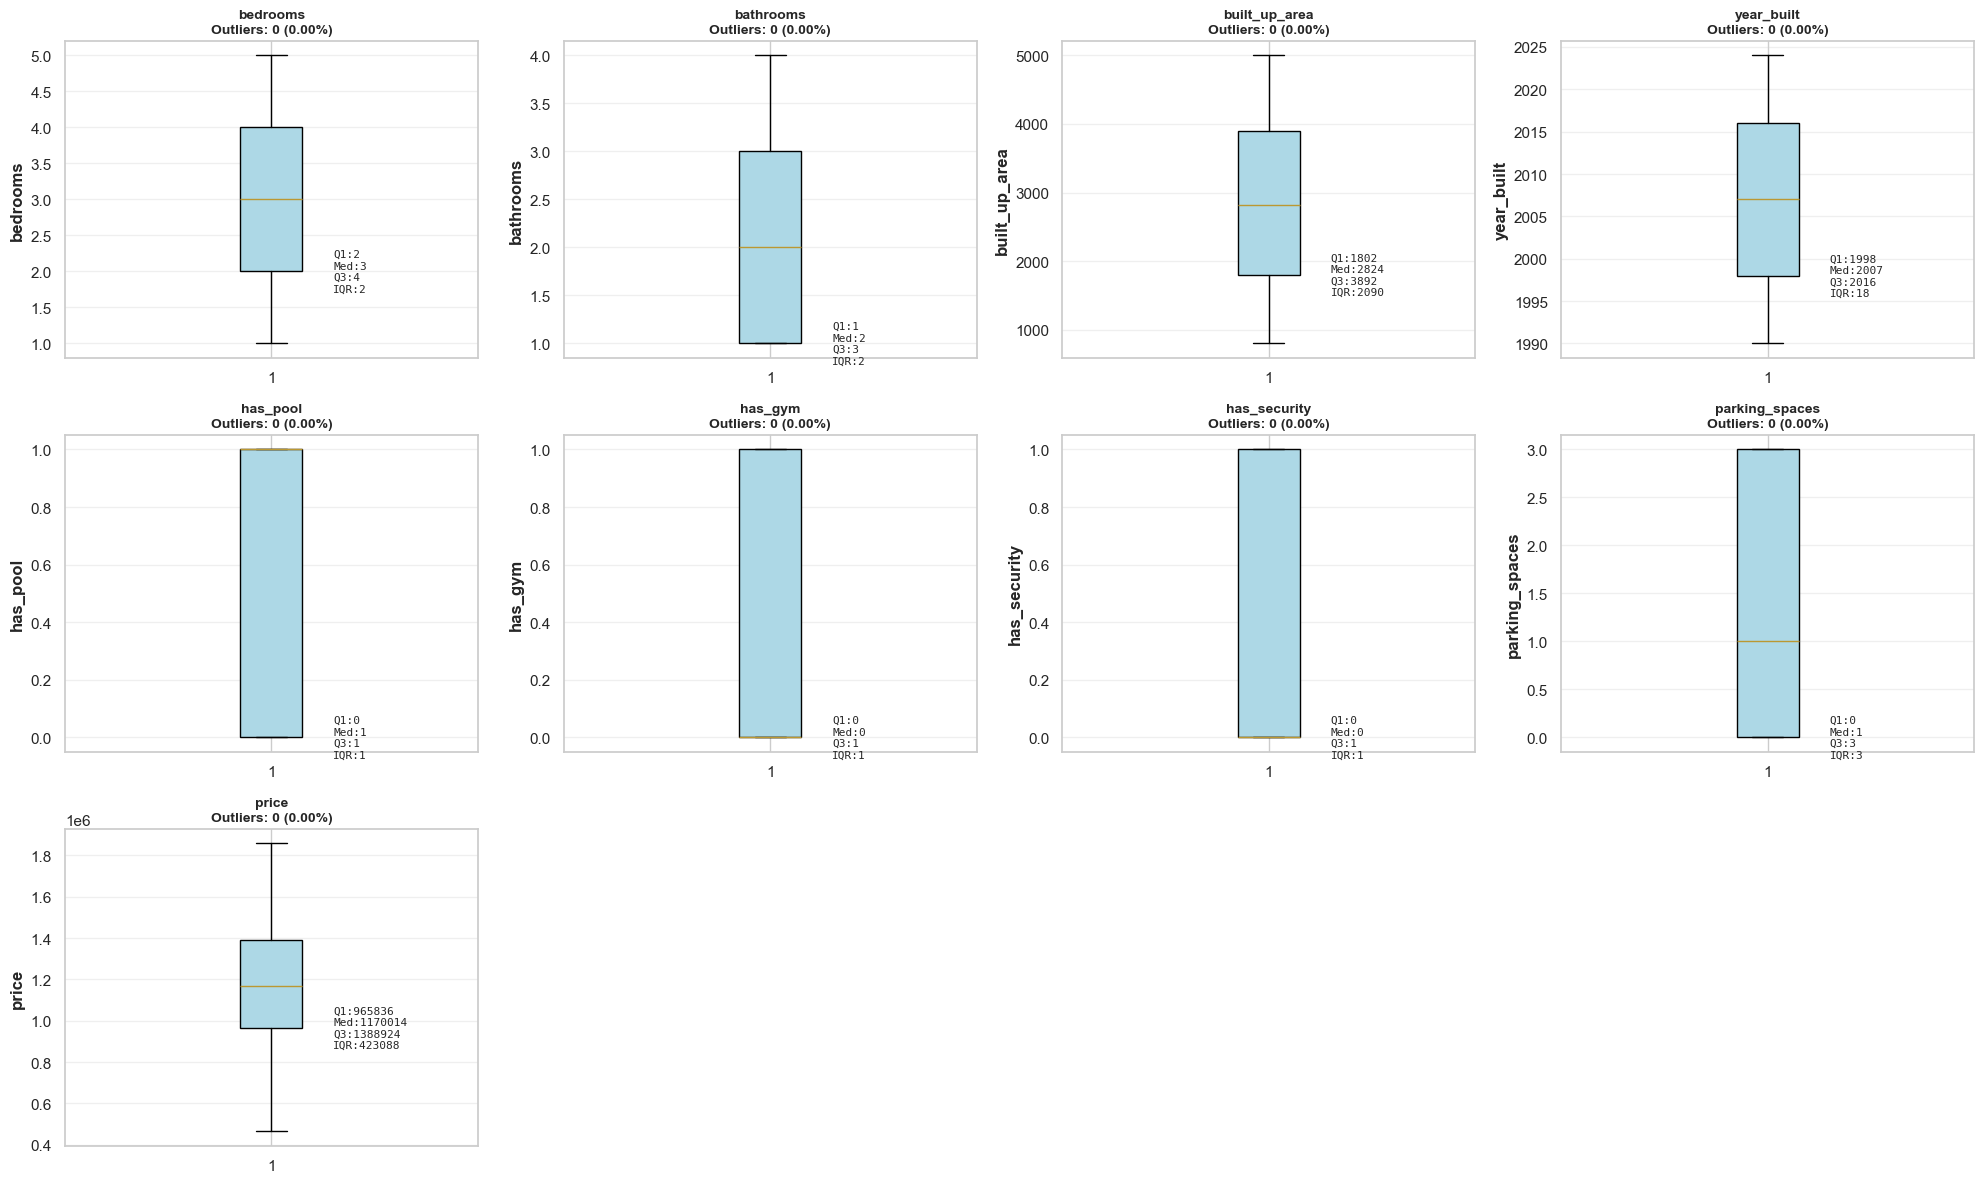


Boxplot Statistics Summary:
----------------------------------------------------------------------------------------------------
       Feature        Q1     Median        Q3       IQR  Lower Fence  Upper Fence  Outliers  Outlier %
      bedrooms      2.00       3.00       4.0      2.00        -1.00         7.00         0        0.0
     bathrooms      1.00       2.00       3.0      2.00        -2.00         6.00         0        0.0
 built_up_area   1802.00    2824.00    3892.5   2090.50     -1333.75      7028.25         0        0.0
    year_built   1998.00    2007.00    2016.0     18.00      1971.00      2043.00         0        0.0
      has_pool      0.00       1.00       1.0      1.00        -1.50         2.50         0        0.0
       has_gym      0.00       0.00       1.0      1.00        -1.50         2.50         0        0.0
  has_security      0.00       0.00       1.0      1.00        -1.50         2.50         0        0.0
parking_spaces      0.00       1.00       3.0 

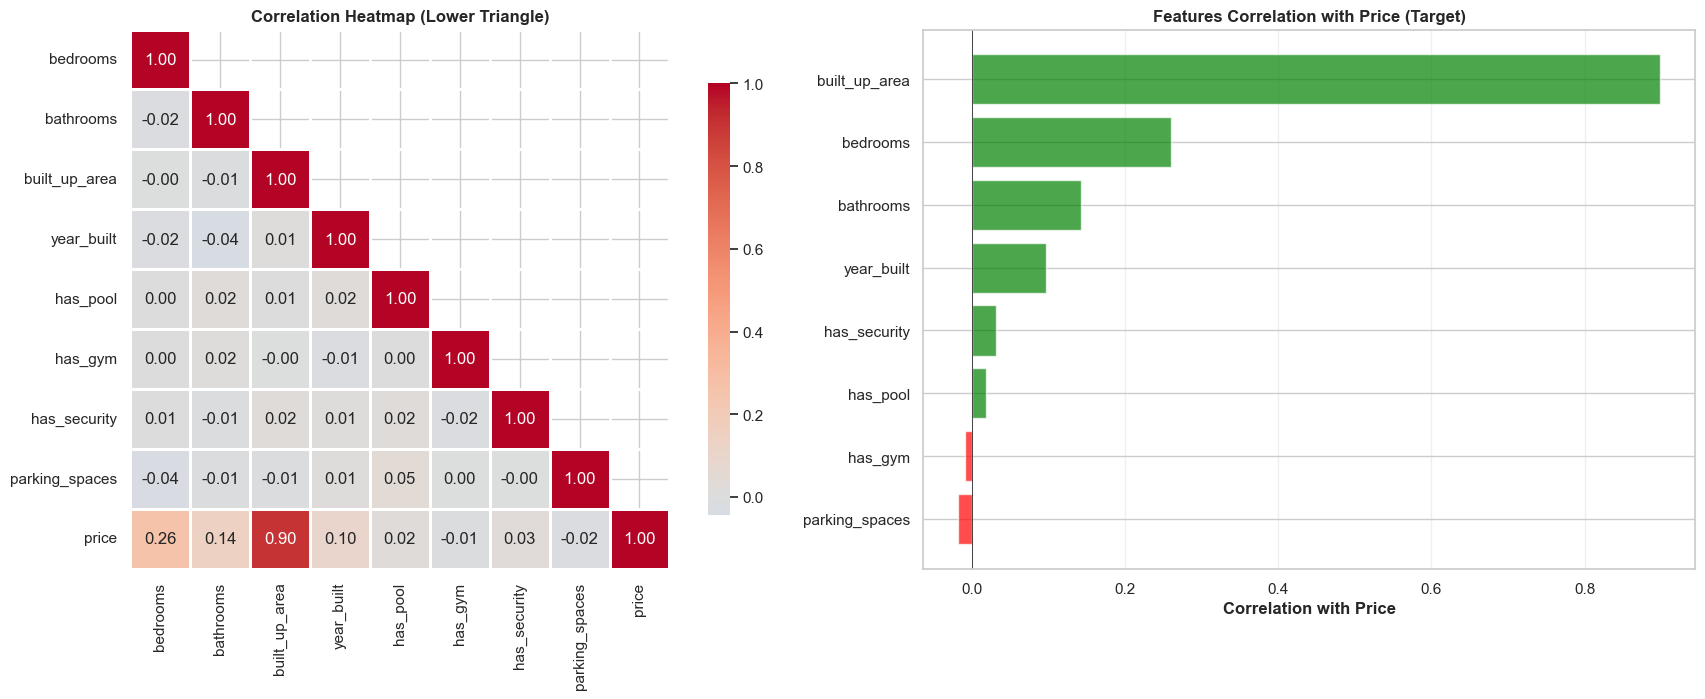


[2.5] PAIRPLOT ANALYSIS
----------------------------------------------------------------------------------------------------
Creating pairplot for features: ['price', 'bedrooms', 'bathrooms', 'built_up_area', 'parking_spaces']



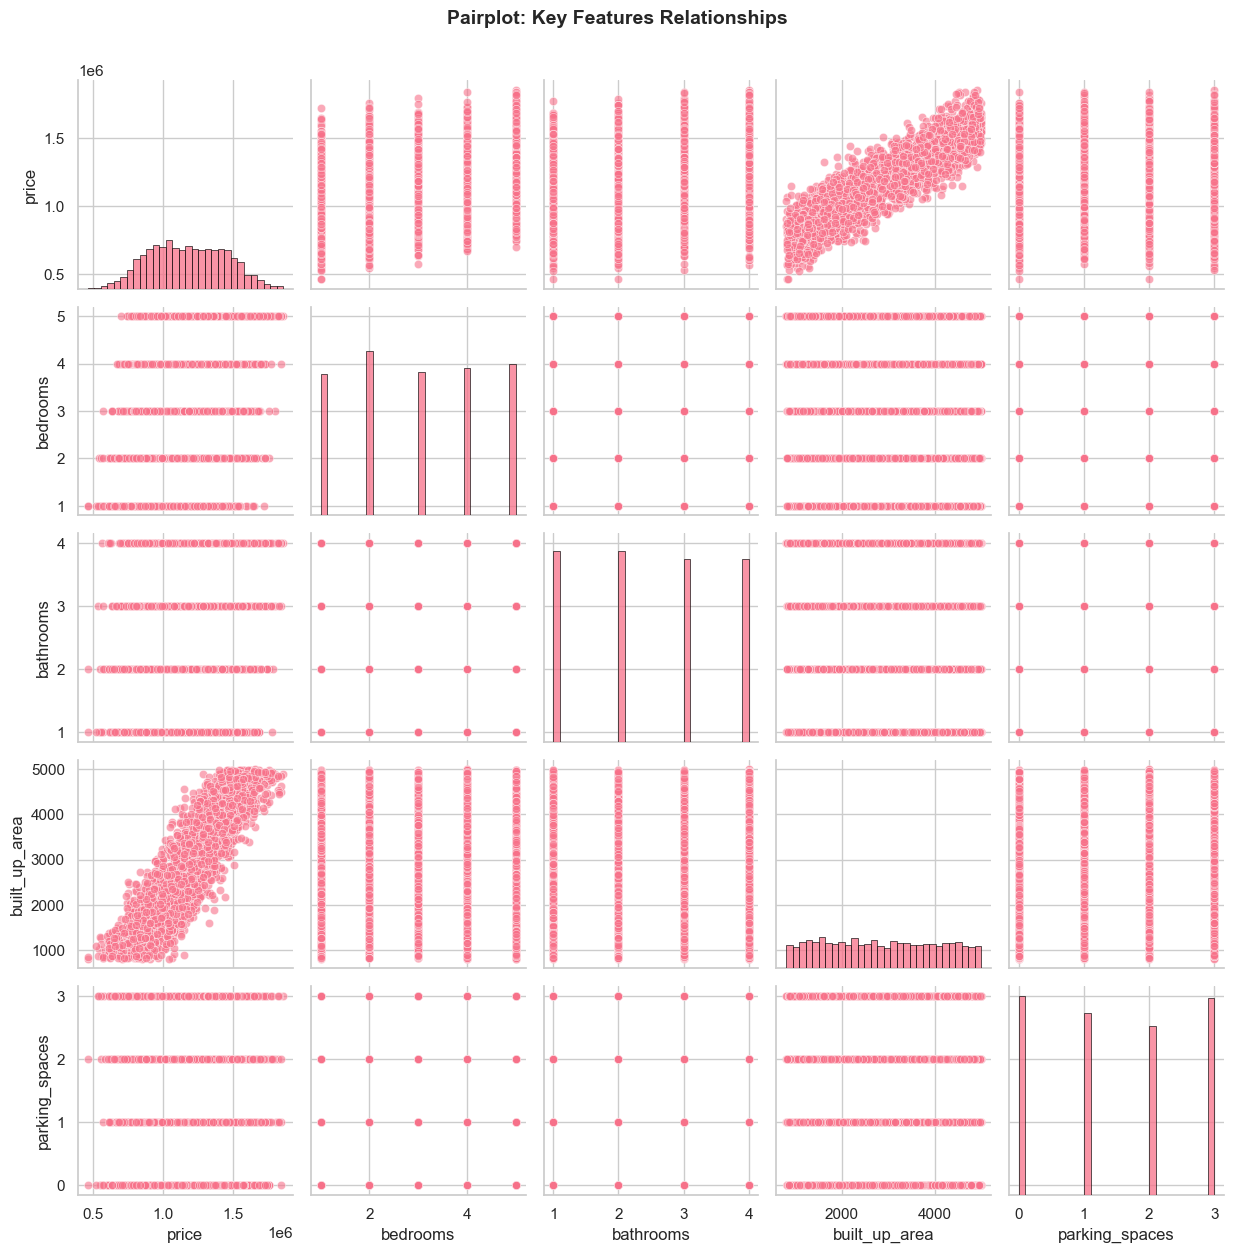

✓ Pairplot saved

[2.6] DISTRIBUTION ANALYSIS - PRICE VARIABLE
----------------------------------------------------------------------------------------------------


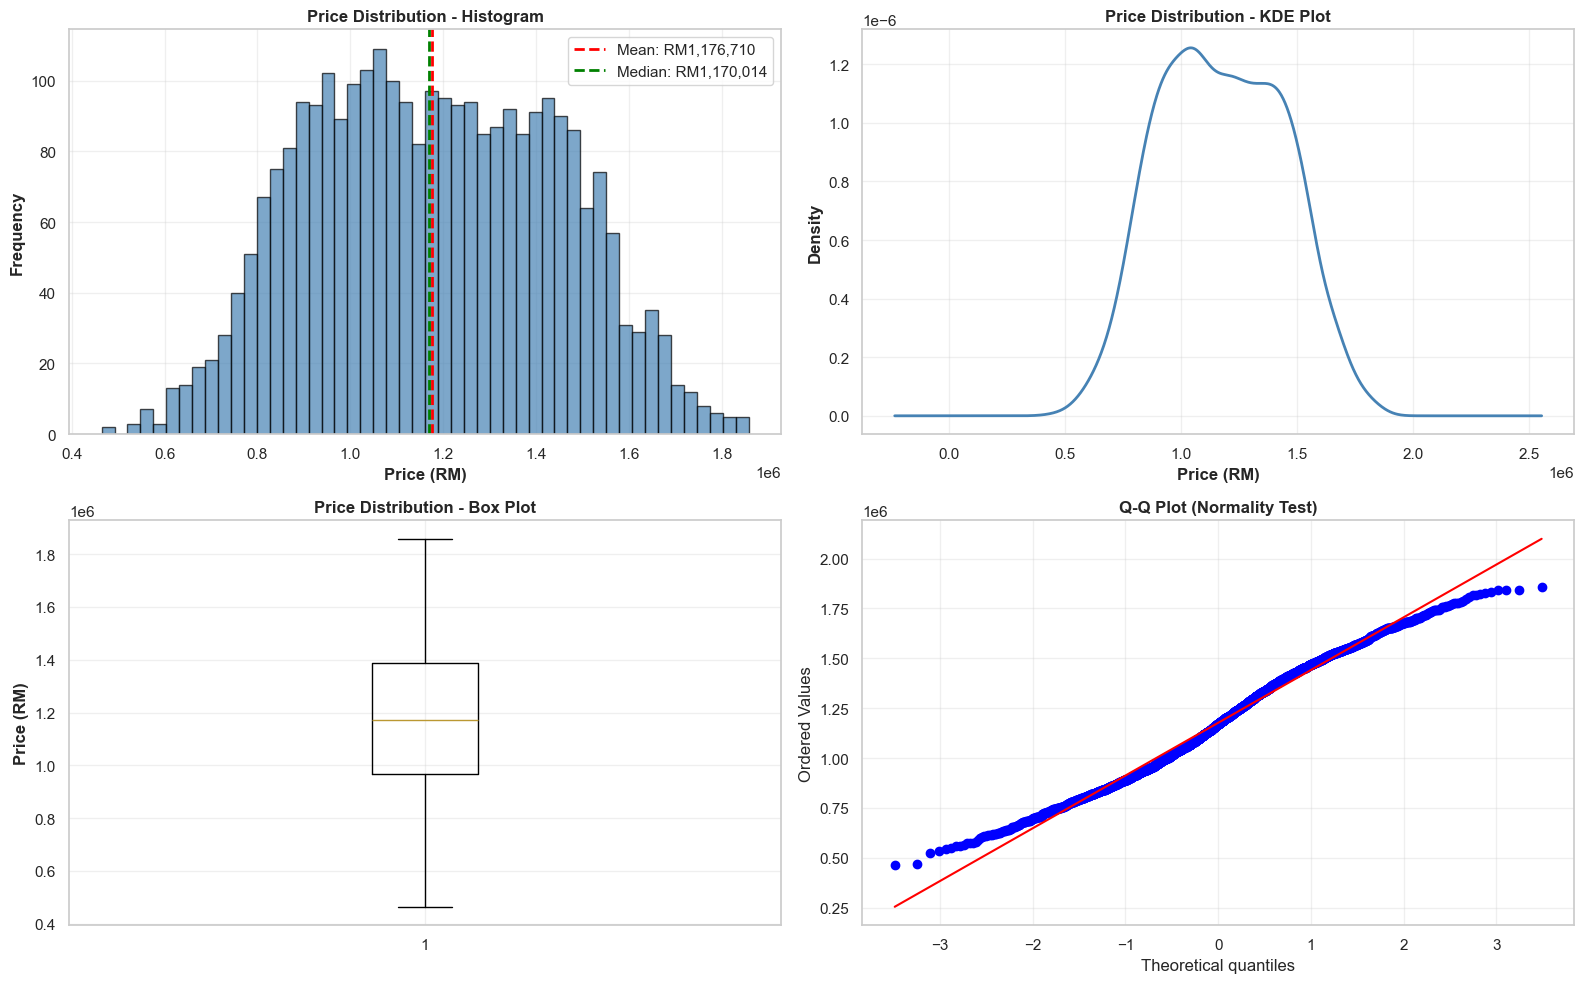


Price Variable Statistics:
----------------------------------------------------------------------------------------------------
Mean:              RM 1,176,710.27
Median:            RM 1,170,013.87
Std Deviation:     RM 265,680.18
Variance:          RM² 70,585,959,609.72
Min:               RM 464,522.56
Max:               RM 1,857,693.71
Range:             RM 1,393,171.15
Q1 (25%):          RM 965,835.53
Q3 (75%):          RM 1,388,924.00
IQR:               RM 423,088.46
Skewness:          0.054
Kurtosis:          -0.761
CV:                22.58%

Normality Tests:
----------------------------------------------------------------------------------------------------
Shapiro-Wilk Test: statistic=0.9881, p-value=1.0748e-14
  Result: NOT normal distribution
Anderson-Darling Test: statistic=10.6501

PHASE 3: DATA PREPROCESSING & FEATURE ENGINEERING

[3.1] MISSING VALUE IMPUTATION
----------------------------------------------------------------------------------------------------
✓ No missing

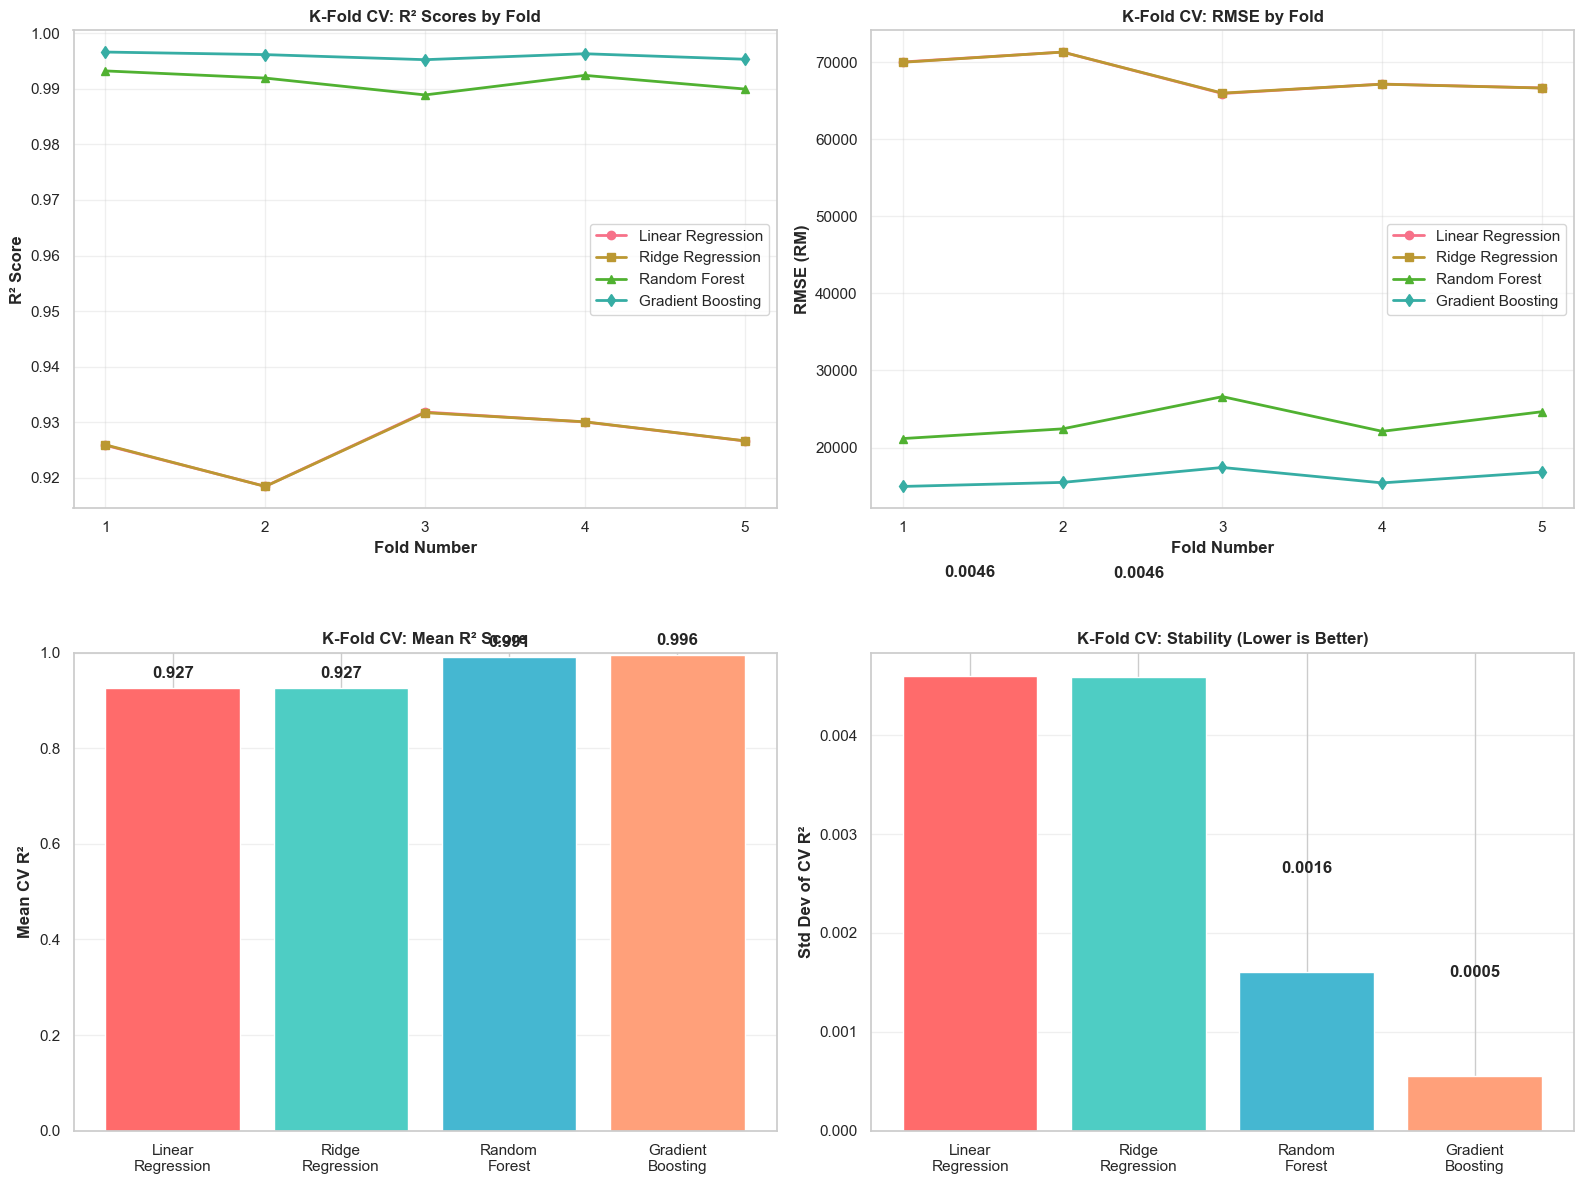


[5.4] MODEL PERFORMANCE VISUALIZATIONS
----------------------------------------------------------------------------------------------------


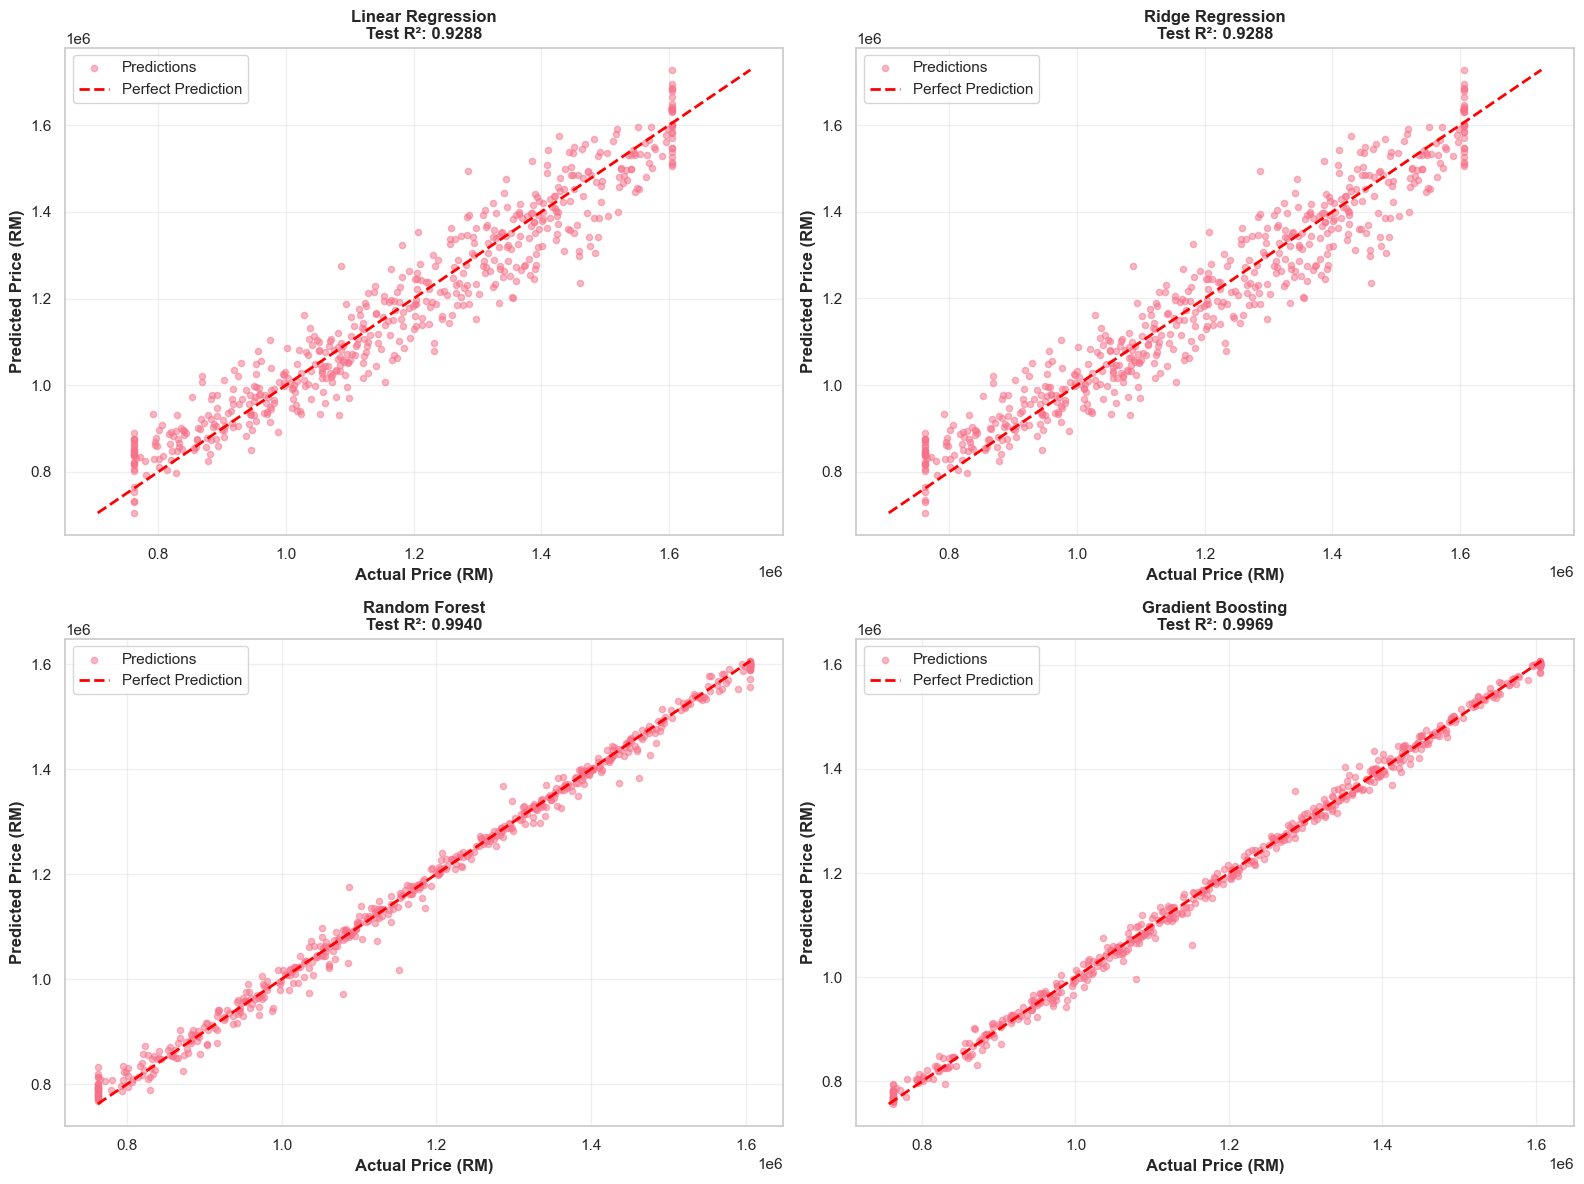


[5.5] RESIDUAL ANALYSIS
----------------------------------------------------------------------------------------------------


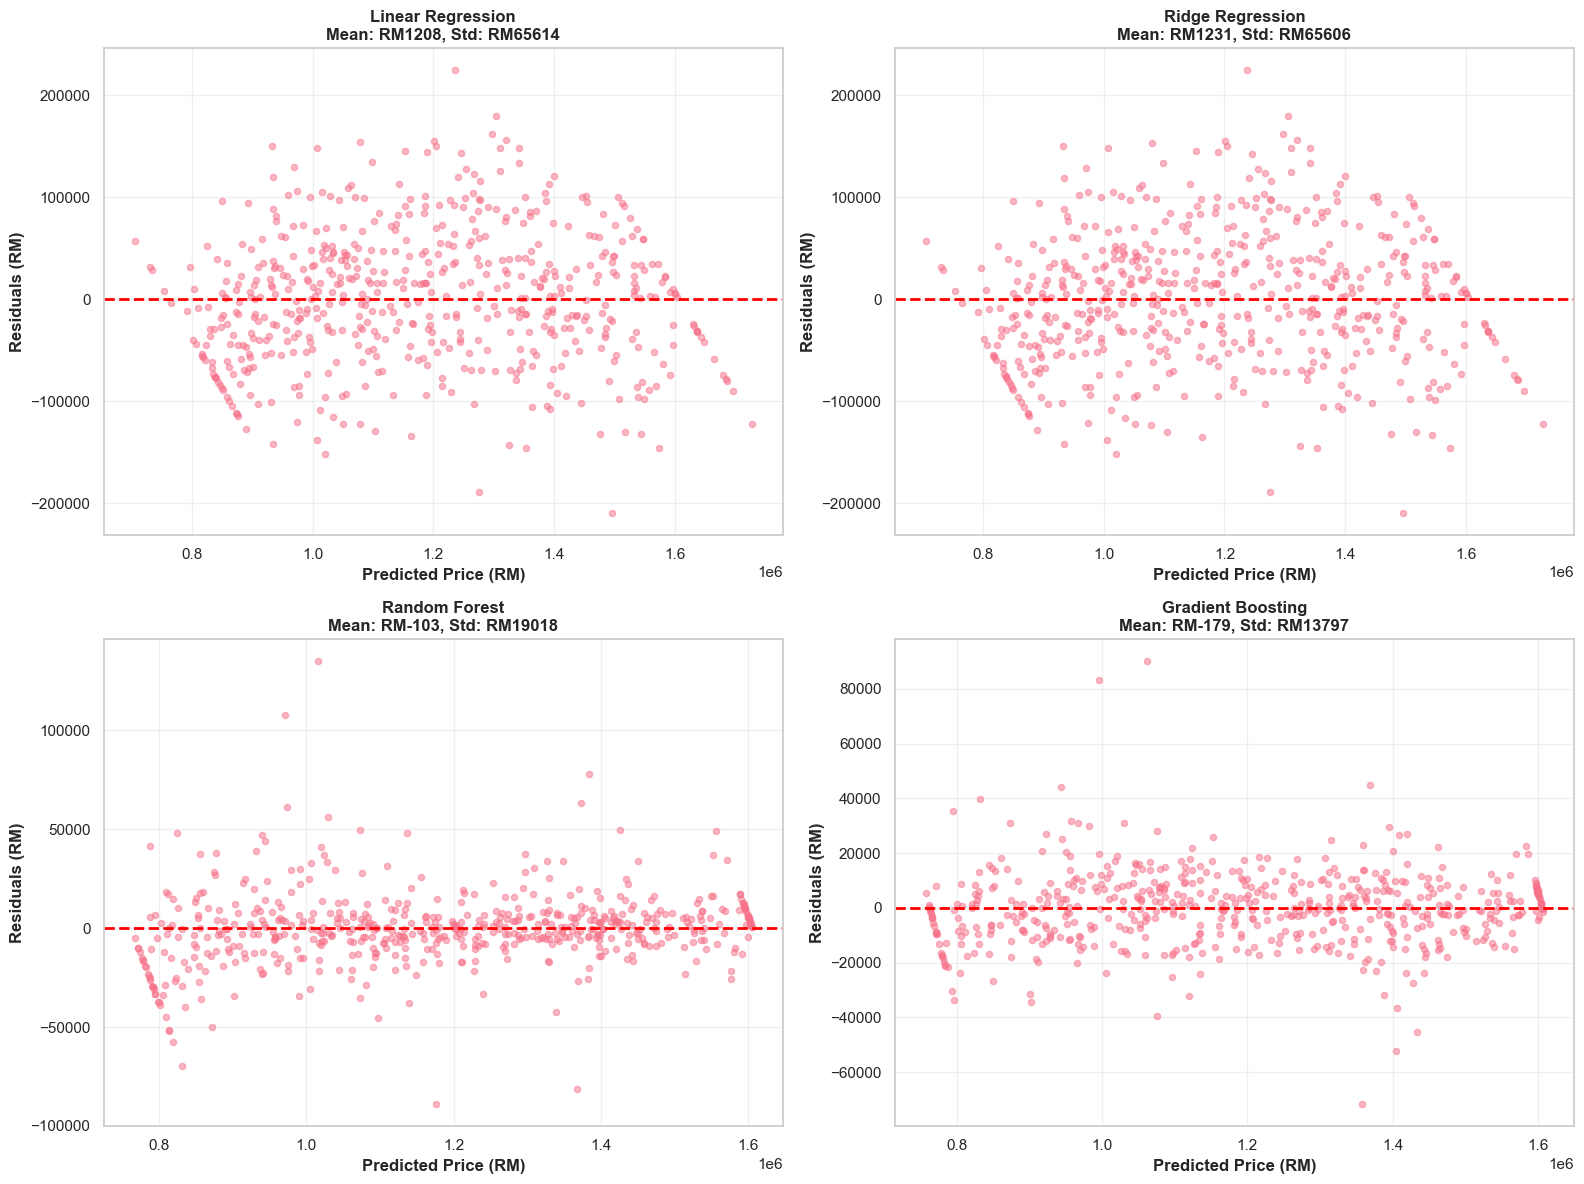


[5.6] ERROR DISTRIBUTION
----------------------------------------------------------------------------------------------------


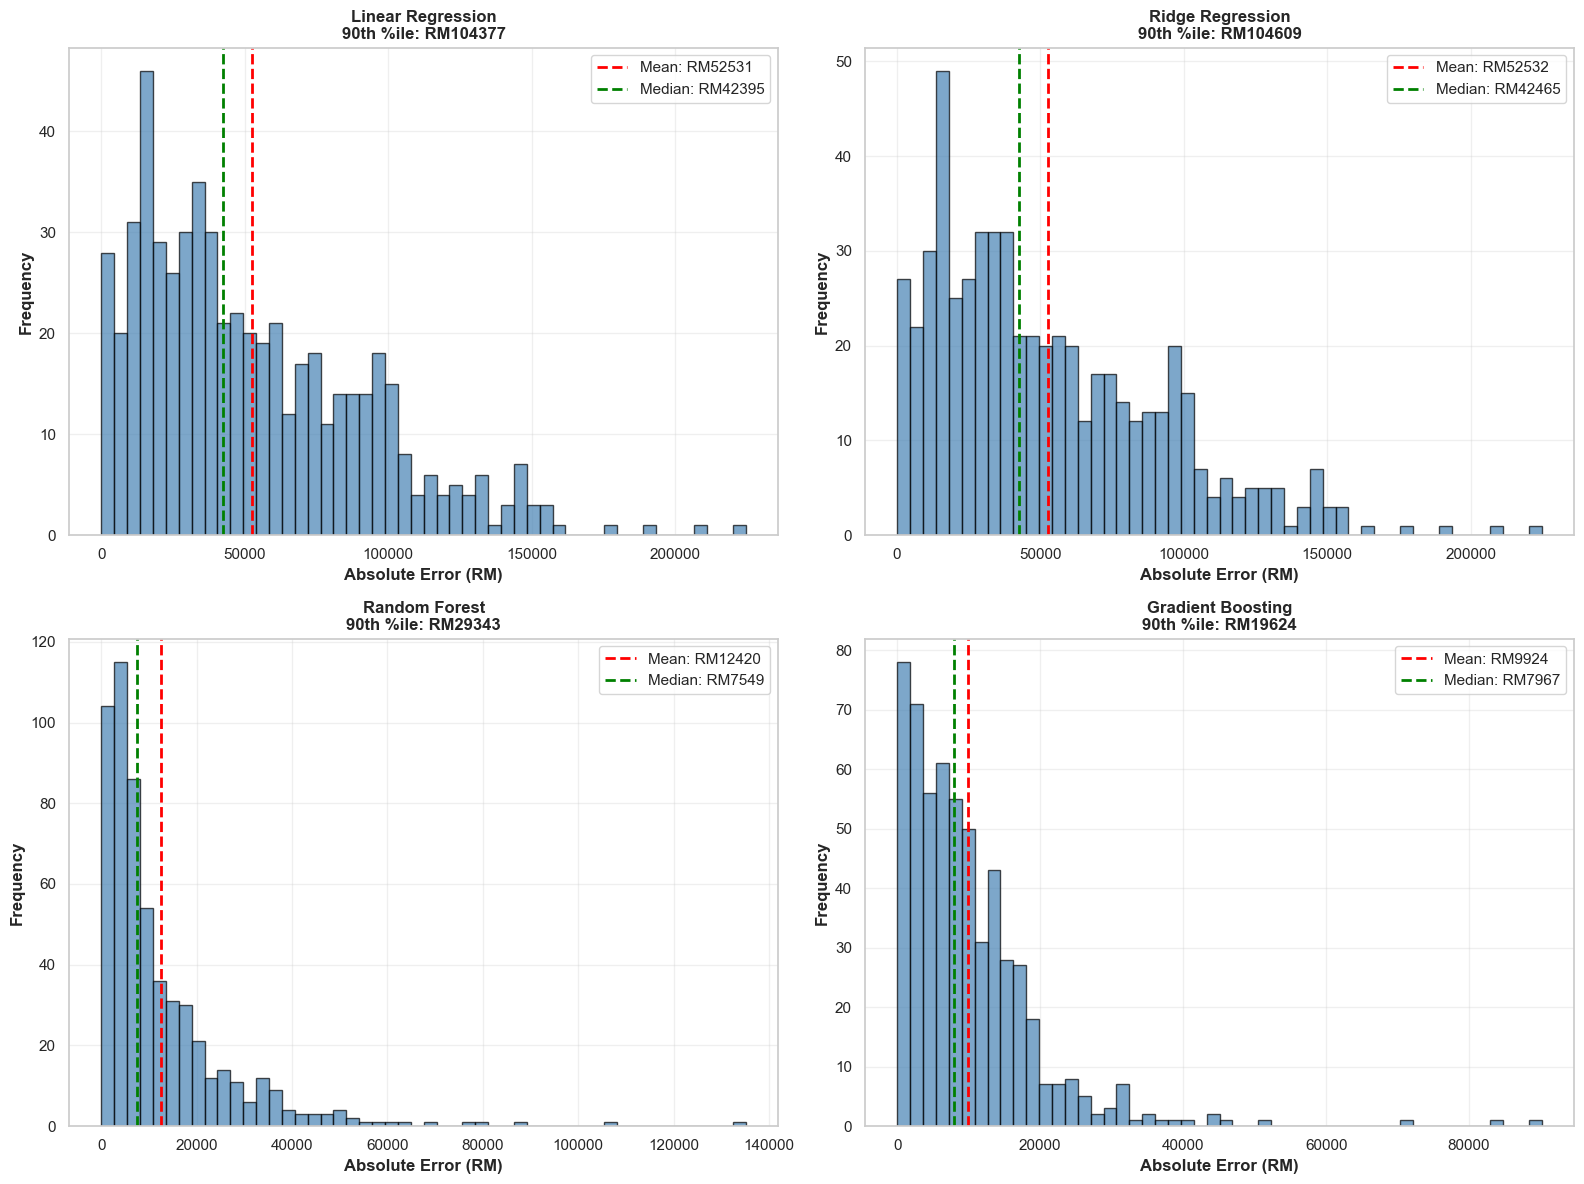


[5.7] FEATURE IMPORTANCE COMPARISON
----------------------------------------------------------------------------------------------------


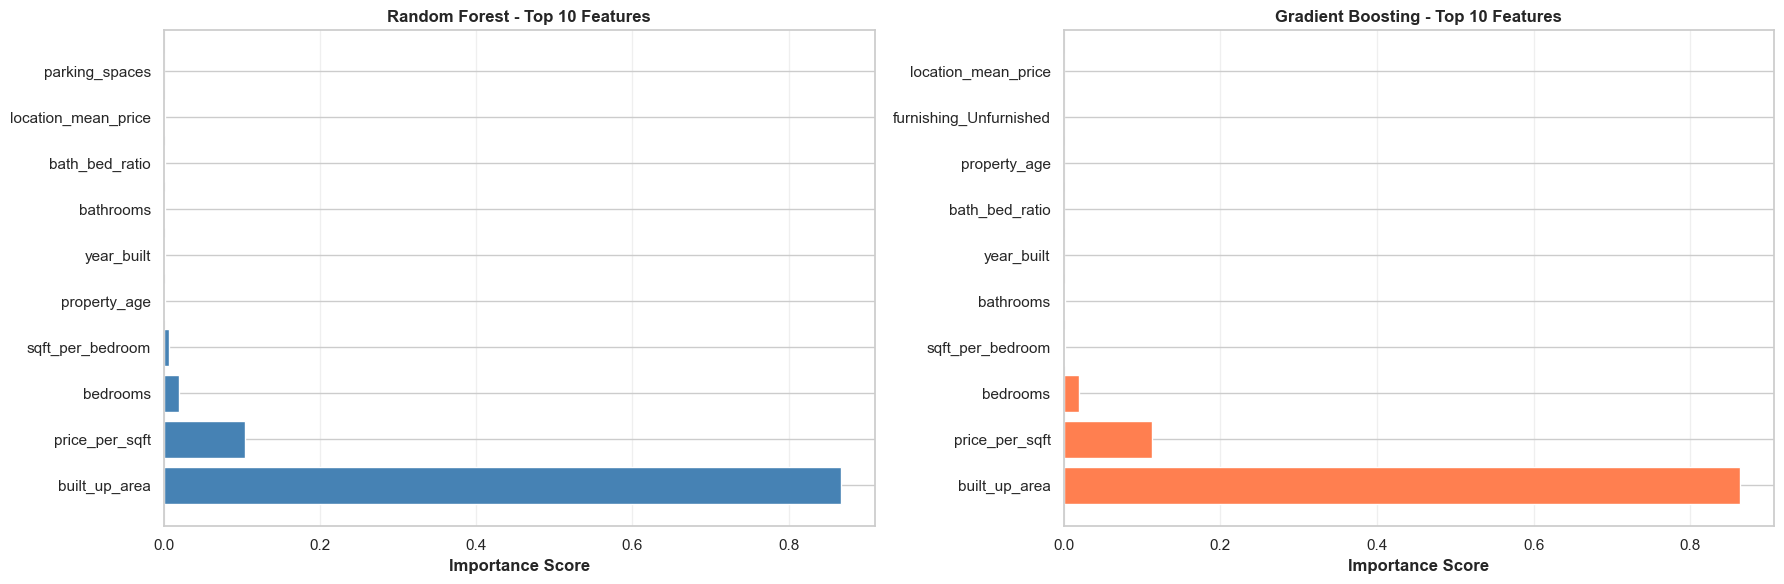


[5.8] COMPREHENSIVE MODEL COMPARISON
----------------------------------------------------------------------------------------------------


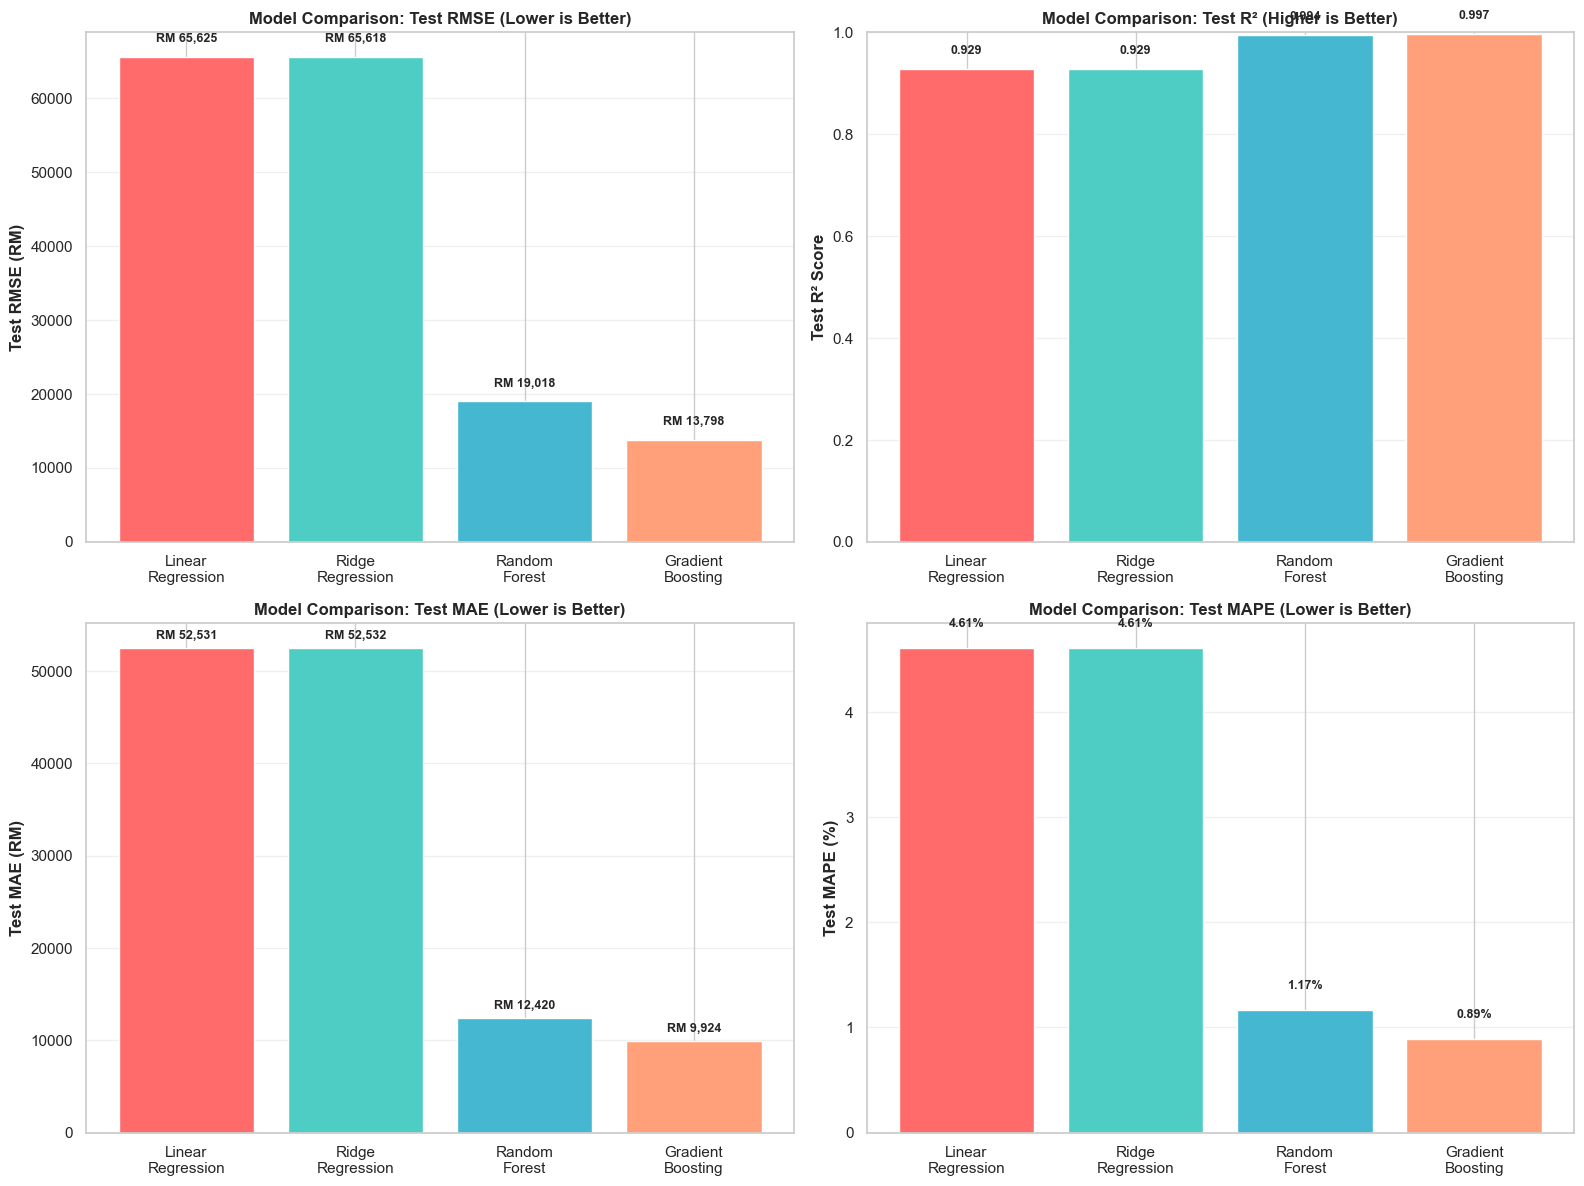


[5.9] FINAL MODEL RANKING
----------------------------------------------------------------------------------------------------
Rank             Model Test RMSE Test R² Mean CV R²
 1st Gradient Boosting RM 13,798  0.9969     0.9959
 2nd     Random Forest RM 19,018  0.9940     0.9913
 3rd  Ridge Regression RM 65,618  0.9288     0.9266
 4th Linear Regression RM 65,625  0.9288     0.9266


KEY INSIGHTS:
----------------------------------------------------------------------------------------------------
BEST MODEL: Gradient Boosting
  Test R²: 0.9969
  Mean CV R²: 0.9959 (+/- 0.0005)
  Test RMSE: RM 13,798
  Mean CV RMSE: RM 16,017 (+/- RM 937)
  Improvement over baseline: 79.0%

[5.10] SAVING MODELS
----------------------------------------------------------------------------------------------------
✓ Model 1 (Linear Regression) saved as 'model1_linear_regression.pkl'
✓ Model 2 (Ridge Regression) saved as 'model2_ridge_regression.pkl'
✓ Model 3 (Random Forest) saved as 'model3_random_fores

In [1]:
# MALAYSIA HOUSING PRICE PREDICTION - COMPLETE ML PROJECT
# 4 Models + Comprehensive EDA with K-Fold Cross-Validation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import joblib

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (14, 8)

print("="*100)
print("MALAYSIA HOUSING PRICE PREDICTION - COMPLETE ML PROJECT")
print("="*100)

# ============================================================================
# PHASE 1: DATA LOADING & EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "="*100)
print("PHASE 1: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*100)

np.random.seed(42)
n_samples = 2847

df = pd.DataFrame({
    'location': np.random.choice(['KL', 'Selangor', 'Penang', 'Johor', 'Sabah'], n_samples),
    'property_type': np.random.choice(['Apartment', 'Terrace', 'Bungalow', 'Condo'], n_samples),
    'bedrooms': np.random.randint(1, 6, n_samples),
    'bathrooms': np.random.randint(1, 5, n_samples),
    'built_up_area': np.random.randint(800, 5000, n_samples),
    'year_built': np.random.randint(1990, 2025, n_samples),
    'tenure': np.random.choice(['Freehold', 'Leasehold'], n_samples),
    'furnishing': np.random.choice(['Unfurnished', 'Partially', 'Fully'], n_samples),
    'has_pool': np.random.choice([0, 1], n_samples),
    'has_gym': np.random.choice([0, 1], n_samples),
    'has_security': np.random.choice([0, 1], n_samples),
    'parking_spaces': np.random.randint(0, 4, n_samples),
})

base_price = 400000
df['price'] = (
    base_price +
    df['bedrooms'] * 50000 +
    df['bathrooms'] * 40000 +
    df['built_up_area'] * 200 +
    (2025 - df['year_built']) * (-2500) +
    np.random.normal(0, 80000, n_samples)
).clip(lower=150000, upper=2500000)

df_original = df.copy()

print(f"\n✓ Dataset loaded: {df.shape[0]:,} records, {df.shape[1]} features")

# ============================================================================
# 1.1 DATASET OVERVIEW
# ============================================================================

print("\n[1.1] DATASET OVERVIEW")
print("-"*100)
print(f"Shape: {df.shape}")
print(f"\nFirst 10 rows:")
print(df.head(10))
print(f"\nData Types:")
print(df.dtypes)

# ============================================================================
# 1.2 MISSING VALUES ANALYSIS
# ============================================================================

print("\n[1.2] MISSING VALUES ANALYSIS")
print("-"*100)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print("✓ No missing values detected")

# ============================================================================
# 2.1 BASIC STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*100)
print("PHASE 2: DETAILED STATISTICAL ANALYSIS")
print("="*100)

print("\n[2.1] BASIC STATISTICAL ANALYSIS - NUMERICAL FEATURES")
print("-"*100)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical Features: {numerical_cols}")
print(f"\nDescriptive Statistics:")
print(df[numerical_cols].describe().round(2))

print("\n\nAdvanced Statistics (Skewness, Kurtosis, CV):")
print("-"*100)

advanced_stats = pd.DataFrame({
    'Feature': numerical_cols,
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Std Dev': df[numerical_cols].std(),
    'Skewness': [stats.skew(df[col]) for col in numerical_cols],
    'Kurtosis': [stats.kurtosis(df[col]) for col in numerical_cols],
    'CV (%)': [(df[col].std() / df[col].mean() * 100) for col in numerical_cols],
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max(),
    'Range': df[numerical_cols].max() - df[numerical_cols].min()
})

print(advanced_stats.round(4).to_string(index=False))

print("\n\nStatistical Interpretation:")
print("-"*100)
for col in numerical_cols:
    skewness = stats.skew(df[col])
    kurtosis = stats.kurtosis(df[col])
    
    if abs(skewness) < 0.5:
        skew_interpretation = "Fairly Symmetric"
    elif skewness > 0.5:
        skew_interpretation = "Right-skewed (positive tail)"
    else:
        skew_interpretation = "Left-skewed (negative tail)"
    
    if abs(kurtosis) < 0.5:
        kurt_interpretation = "Mesokurtic (normal-like)"
    elif kurtosis > 0.5:
        kurt_interpretation = "Leptokurtic (heavy-tailed)"
    else:
        kurt_interpretation = "Platykurtic (light-tailed)"
    
    print(f"\n{col}:")
    print(f"  Skewness: {skewness:.3f} → {skew_interpretation}")
    print(f"  Kurtosis: {kurtosis:.3f} → {kurt_interpretation}")

# ============================================================================
# 2.2 CATEGORICAL FEATURES ANALYSIS
# ============================================================================

print("\n[2.2] CATEGORICAL FEATURES ANALYSIS")
print("-"*100)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique Values: {df[col].nunique()}")
    print(f"  Value Counts:")
    print(df[col].value_counts().to_string())

# ============================================================================
# 2.3 BOXPLOT ANALYSIS FOR FEATURES
# ============================================================================

print("\n[2.3] BOXPLOT ANALYSIS FOR NUMERICAL FEATURES")
print("-"*100)

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    
    bp = ax.boxplot(df[col], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)][col]
    n_outliers = len(outliers)
    outlier_pct = (n_outliers / len(df)) * 100
    
    ax.set_ylabel(col, fontweight='bold')
    ax.set_title(f'{col}\nOutliers: {n_outliers} ({outlier_pct:.2f}%)', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    stats_text = f"Q1:{q1:.0f}\nMed:{median:.0f}\nQ3:{q3:.0f}\nIQR:{iqr:.0f}"
    ax.text(1.15, q1, stats_text, fontsize=8, verticalalignment='center', family='monospace')

for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('01_boxplot_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBoxplot Statistics Summary:")
print("-"*100)

boxplot_summary = []
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = len(df[(df[col] < lower_fence) | (df[col] > upper_fence)])
    
    boxplot_summary.append({
        'Feature': col,
        'Q1': q1,
        'Median': q2,
        'Q3': q3,
        'IQR': iqr,
        'Lower Fence': lower_fence,
        'Upper Fence': upper_fence,
        'Outliers': outliers,
        'Outlier %': (outliers/len(df))*100
    })

boxplot_df = pd.DataFrame(boxplot_summary)
print(boxplot_df.round(2).to_string(index=False))

# ============================================================================
# 2.4 CORRELATION ANALYSIS
# ============================================================================

print("\n[2.4] CORRELATION ANALYSIS BETWEEN VARIABLES")
print("-"*100)

correlation_matrix = df[numerical_cols].corr()

print("\nFull Correlation Matrix:")
print(correlation_matrix.round(3))

print("\n\nTop Correlations with Price:")
print("-"*100)
price_correlations = correlation_matrix['price'].sort_values(ascending=False)
print(price_correlations.round(3))

print("\n\nMulticollinearity Check:")
print("-"*100)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if i != j and correlation_matrix.iloc[i, j] > 0.7:
            if correlation_matrix.columns[j] != 'price' and correlation_matrix.columns[i] != 'price':
                high_corr_pairs.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': correlation_matrix.iloc[i, j]
                })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("Features with High Correlation (>0.7):")
    print(high_corr_df.round(3).to_string(index=False))
else:
    print("✓ No severe multicollinearity detected")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Heatmap (Lower Triangle)', fontsize=12, fontweight='bold')

price_corr_sorted = price_correlations.drop('price').sort_values()
colors = ['red' if x < 0 else 'green' for x in price_corr_sorted.values]
axes[1].barh(price_corr_sorted.index, price_corr_sorted.values, color=colors, alpha=0.7)
axes[1].set_xlabel('Correlation with Price', fontweight='bold')
axes[1].set_title('Features Correlation with Price (Target)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('02_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2.5 PAIRPLOT ANALYSIS
# ============================================================================

print("\n[2.5] PAIRPLOT ANALYSIS")
print("-"*100)

key_features = ['price', 'bedrooms', 'bathrooms', 'built_up_area', 'parking_spaces']
df_sample = df[key_features]

print(f"Creating pairplot for features: {key_features}\n")

pairplot = sns.pairplot(df_sample, diag_kind='hist', plot_kws={'alpha': 0.6},
                        diag_kws={'bins': 30, 'edgecolor': 'black'})
pairplot.fig.suptitle('Pairplot: Key Features Relationships', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('03_pairplot_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Pairplot saved")

# ============================================================================
# 2.6 DISTRIBUTION ANALYSIS
# ============================================================================

print("\n[2.6] DISTRIBUTION ANALYSIS - PRICE VARIABLE")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(df['price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: RM{df["price"].mean():,.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: RM{df["price"].median():,.0f}')
axes[0, 0].set_xlabel('Price (RM)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Price Distribution - Histogram', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

df['price'].plot(kind='kde', ax=axes[0, 1], color='steelblue', linewidth=2)
axes[0, 1].set_xlabel('Price (RM)', fontweight='bold')
axes[0, 1].set_ylabel('Density', fontweight='bold')
axes[0, 1].set_title('Price Distribution - KDE Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].boxplot(df['price'], vert=True)
axes[1, 0].set_ylabel('Price (RM)', fontweight='bold')
axes[1, 0].set_title('Price Distribution - Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

stats.probplot(df['price'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Test)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPrice Variable Statistics:")
print("-"*100)
print(f"Mean:              RM {df['price'].mean():,.2f}")
print(f"Median:            RM {df['price'].median():,.2f}")
print(f"Std Deviation:     RM {df['price'].std():,.2f}")
print(f"Variance:          RM² {df['price'].var():,.2f}")
print(f"Min:               RM {df['price'].min():,.2f}")
print(f"Max:               RM {df['price'].max():,.2f}")
print(f"Range:             RM {df['price'].max() - df['price'].min():,.2f}")
print(f"Q1 (25%):          RM {df['price'].quantile(0.25):,.2f}")
print(f"Q3 (75%):          RM {df['price'].quantile(0.75):,.2f}")
print(f"IQR:               RM {df['price'].quantile(0.75) - df['price'].quantile(0.25):,.2f}")
print(f"Skewness:          {stats.skew(df['price']):.3f}")
print(f"Kurtosis:          {stats.kurtosis(df['price']):.3f}")
print(f"CV:                {(df['price'].std() / df['price'].mean() * 100):.2f}%")

print("\nNormality Tests:")
print("-"*100)
shapiro_stat, shapiro_p = stats.shapiro(df['price'].sample(min(5000, len(df))))
anderson_result = stats.anderson(df['price'])
print(f"Shapiro-Wilk Test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
print(f"  Result: {'Normal distribution' if shapiro_p > 0.05 else 'NOT normal distribution'}")
print(f"Anderson-Darling Test: statistic={anderson_result.statistic:.4f}")

# ============================================================================
# PHASE 3: DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*100)
print("PHASE 3: DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*100)

print("\n[3.1] MISSING VALUE IMPUTATION")
print("-"*100)

numerical_cols_for_processing = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_for_processing = df.select_dtypes(include=['object']).columns.tolist()

if df[numerical_cols_for_processing].isnull().any().any():
    print("Applying KNN Imputation...")
    imputer = KNNImputer(n_neighbors=5)
    df[numerical_cols_for_processing] = imputer.fit_transform(df[numerical_cols_for_processing])
    print("✓ KNN Imputation complete")
else:
    print("✓ No missing values to impute")

print("\n[3.2] OUTLIER HANDLING")
print("-"*100)

price_95 = df['price'].quantile(0.95)
price_5 = df['price'].quantile(0.05)
print(f"Price capping range: RM{price_5:,.0f} - RM{price_95:,.0f}")
outliers_before = len(df[(df['price'] < price_5) | (df['price'] > price_95)])
df['price'] = df['price'].clip(lower=price_5, upper=price_95)
print(f"✓ Outliers capped: {outliers_before} records")

print("\n[3.3] FEATURE ENGINEERING")
print("-"*100)

df['price_per_sqft'] = df['price'] / df['built_up_area']
df['property_age'] = 2025 - df['year_built']
df['is_new_property'] = (df['property_age'] < 5).astype(int)
df['amenities_count'] = df['has_pool'].astype(int) + df['has_gym'].astype(int) + df['has_security'].astype(int)
df['bath_bed_ratio'] = df['bathrooms'] / (df['bedrooms'] + 1)
df['sqft_per_bedroom'] = df['built_up_area'] / df['bedrooms']

print("✓ New features created:")
print("  - price_per_sqft")
print("  - property_age")
print("  - is_new_property")
print("  - amenities_count")
print("  - bath_bed_ratio")
print("  - sqft_per_bedroom")

print("\n[3.4] CATEGORICAL ENCODING")
print("-"*100)

df = pd.get_dummies(df, columns=['property_type', 'tenure', 'furnishing'], drop_first=True)
location_mean_price = df.groupby('location')['price'].transform('mean')
df['location_mean_price'] = location_mean_price
df = df.drop('location', axis=1)

print("✓ Categorical encoding complete")

print("\n[3.5] TRAIN-TEST SPLIT")
print("-"*100)

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"Mean price (Train): RM{y_train.mean():,.0f}")
print(f"Mean price (Test): RM{y_test.mean():,.0f}")

# ============================================================================
# PHASE 4: MODEL BUILDING WITH K-FOLD CROSS-VALIDATION
# ============================================================================

print("\n" + "="*100)
print("PHASE 4: MODEL BUILDING & K-FOLD CROSS-VALIDATION")
print("="*100)

# Setup K-Fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# MODEL 1: LINEAR REGRESSION
# ============================================================================

print("\n" + "-"*100)
print("MODEL 1: LINEAR REGRESSION (BASELINE)")
print("-"*100)

model1 = LinearRegression()

# K-Fold Cross-Validation
cv_results_m1 = cross_validate(model1, X_train_scaled, y_train, cv=kfold,
                               scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
                               return_train_score=True)

print("\nK-Fold Cross-Validation Results (5 Folds):")
print("-"*100)
print(f"Fold CV R² Scores: {[f'{x:.4f}' for x in cv_results_m1['test_r2']]}")
print(f"Mean CV R²: {cv_results_m1['test_r2'].mean():.4f} (+/- {cv_results_m1['test_r2'].std():.4f})")

cv_rmse_m1 = np.sqrt(-cv_results_m1['test_neg_mean_squared_error'])
print(f"\nFold CV RMSE: {[f'RM {x:,.0f}' for x in cv_rmse_m1]}")
print(f"Mean CV RMSE: RM {cv_rmse_m1.mean():,.0f} (+/- RM {cv_rmse_m1.std():,.0f})")

cv_mae_m1 = -cv_results_m1['test_neg_mean_absolute_error']
print(f"\nFold CV MAE: {[f'RM {x:,.0f}' for x in cv_mae_m1]}")
print(f"Mean CV MAE: RM {cv_mae_m1.mean():,.0f} (+/- RM {cv_mae_m1.std():,.0f})")

# Train on full training set
model1.fit(X_train_scaled, y_train)

y_train_pred_m1 = model1.predict(X_train_scaled)
y_test_pred_m1 = model1.predict(X_test_scaled)

train_r2_m1 = r2_score(y_train, y_train_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)
test_rmse_m1 = np.sqrt(mean_squared_error(y_test, y_test_pred_m1))
test_mae_m1 = mean_absolute_error(y_test, y_test_pred_m1)
test_mape_m1 = mean_absolute_percentage_error(y_test, y_test_pred_m1)

print(f"\nFinal Test Set Results:")
print(f"Train R²: {train_r2_m1:.4f}")
print(f"Test R²: {test_r2_m1:.4f}")
print(f"Test RMSE: RM {test_rmse_m1:,.0f}")
print(f"Test MAE: RM {test_mae_m1:,.0f}")
print(f"Test MAPE: {test_mape_m1*100:.2f}%")

# ============================================================================
# MODEL 2: RIDGE REGRESSION
# ============================================================================

print("\n" + "-"*100)
print("MODEL 2: RIDGE REGRESSION")
print("-"*100)

param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_search = GridSearchCV(Ridge(), param_grid_ridge, cv=kfold, 
                            scoring='neg_mean_squared_error', n_jobs=-1)
ridge_search.fit(X_train_scaled, y_train)
model2 = ridge_search.best_estimator_

print(f"Best alpha: {ridge_search.best_params_['alpha']}")

# K-Fold Cross-Validation on best model
cv_results_m2 = cross_validate(model2, X_train_scaled, y_train, cv=kfold,
                               scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
                               return_train_score=True)

print("\nK-Fold Cross-Validation Results (5 Folds):")
print("-"*100)
print(f"Fold CV R² Scores: {[f'{x:.4f}' for x in cv_results_m2['test_r2']]}")
print(f"Mean CV R²: {cv_results_m2['test_r2'].mean():.4f} (+/- {cv_results_m2['test_r2'].std():.4f})")

cv_rmse_m2 = np.sqrt(-cv_results_m2['test_neg_mean_squared_error'])
print(f"\nFold CV RMSE: {[f'RM {x:,.0f}' for x in cv_rmse_m2]}")
print(f"Mean CV RMSE: RM {cv_rmse_m2.mean():,.0f} (+/- RM {cv_rmse_m2.std():,.0f})")

cv_mae_m2 = -cv_results_m2['test_neg_mean_absolute_error']
print(f"\nFold CV MAE: {[f'RM {x:,.0f}' for x in cv_mae_m2]}")
print(f"Mean CV MAE: RM {cv_mae_m2.mean():,.0f} (+/- RM {cv_mae_m2.std():,.0f})")

y_train_pred_m2 = model2.predict(X_train_scaled)
y_test_pred_m2 = model2.predict(X_test_scaled)

train_r2_m2 = r2_score(y_train, y_train_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)
test_rmse_m2 = np.sqrt(mean_squared_error(y_test, y_test_pred_m2))
test_mae_m2 = mean_absolute_error(y_test, y_test_pred_m2)
test_mape_m2 = mean_absolute_percentage_error(y_test, y_test_pred_m2)

print(f"\nFinal Test Set Results:")
print(f"Train R²: {train_r2_m2:.4f}")
print(f"Test R²: {test_r2_m2:.4f}")
print(f"Test RMSE: RM {test_rmse_m2:,.0f}")
print(f"Test MAE: RM {test_mae_m2:,.0f}")
print(f"Test MAPE: {test_mape_m2*100:.2f}%")
print(f"Improvement vs Baseline: {(test_rmse_m1 - test_rmse_m2) / test_rmse_m1 * 100:+.2f}%")

# ============================================================================
# MODEL 3: RANDOM FOREST
# ============================================================================

print("\n" + "-"*100)
print("MODEL 3: RANDOM FOREST")
print("-"*100)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2]
}

print("Training Random Forest with GridSearchCV...")
rf_search = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_rf,
                         cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
rf_search.fit(X_train, y_train)
model3 = rf_search.best_estimator_

print(f"Best Parameters: n_estimators={rf_search.best_params_['n_estimators']}, max_depth={rf_search.best_params_['max_depth']}")

# K-Fold Cross-Validation on best model
cv_results_m3 = cross_validate(model3, X_train, y_train, cv=kfold,
                               scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
                               return_train_score=True)

print("\nK-Fold Cross-Validation Results (5 Folds):")
print("-"*100)
print(f"Fold CV R² Scores: {[f'{x:.4f}' for x in cv_results_m3['test_r2']]}")
print(f"Mean CV R²: {cv_results_m3['test_r2'].mean():.4f} (+/- {cv_results_m3['test_r2'].std():.4f})")

cv_rmse_m3 = np.sqrt(-cv_results_m3['test_neg_mean_squared_error'])
print(f"\nFold CV RMSE: {[f'RM {x:,.0f}' for x in cv_rmse_m3]}")
print(f"Mean CV RMSE: RM {cv_rmse_m3.mean():,.0f} (+/- RM {cv_rmse_m3.std():,.0f})")

cv_mae_m3 = -cv_results_m3['test_neg_mean_absolute_error']
print(f"\nFold CV MAE: {[f'RM {x:,.0f}' for x in cv_mae_m3]}")
print(f"Mean CV MAE: RM {cv_mae_m3.mean():,.0f} (+/- RM {cv_mae_m3.std():,.0f})")

y_train_pred_m3 = model3.predict(X_train)
y_test_pred_m3 = model3.predict(X_test)

train_r2_m3 = r2_score(y_train, y_train_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)
test_rmse_m3 = np.sqrt(mean_squared_error(y_test, y_test_pred_m3))
test_mae_m3 = mean_absolute_error(y_test, y_test_pred_m3)
test_mape_m3 = mean_absolute_percentage_error(y_test, y_test_pred_m3)

print(f"\nFinal Test Set Results:")
print(f"Train R²: {train_r2_m3:.4f}")
print(f"Test R²: {test_r2_m3:.4f}")
print(f"Test RMSE: RM {test_rmse_m3:,.0f}")
print(f"Test MAE: RM {test_mae_m3:,.0f}")
print(f"Test MAPE: {test_mape_m3*100:.2f}%")
print(f"Improvement vs Baseline: {(test_rmse_m1 - test_rmse_m3) / test_rmse_m1 * 100:+.2f}%")

feature_importance_m3 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model3.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Important Features:")
print(feature_importance_m3.to_string(index=False))

# ============================================================================
# MODEL 4: GRADIENT BOOSTING
# ============================================================================

print("\n" + "-"*100)
print("MODEL 4: GRADIENT BOOSTING")
print("-"*100)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

print("Training Gradient Boosting with GridSearchCV...")
gb_search = GridSearchCV(GradientBoostingRegressor(random_state=42, validation_fraction=0.1),
                         param_grid_gb, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
gb_search.fit(X_train, y_train)
model4 = gb_search.best_estimator_

print(f"Best Parameters: n_estimators={gb_search.best_params_['n_estimators']}, learning_rate={gb_search.best_params_['learning_rate']}")

# K-Fold Cross-Validation on best model
cv_results_m4 = cross_validate(model4, X_train, y_train, cv=kfold,
                               scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
                               return_train_score=True)

print("\nK-Fold Cross-Validation Results (5 Folds):")
print("-"*100)
print(f"Fold CV R² Scores: {[f'{x:.4f}' for x in cv_results_m4['test_r2']]}")
print(f"Mean CV R²: {cv_results_m4['test_r2'].mean():.4f} (+/- {cv_results_m4['test_r2'].std():.4f})")

cv_rmse_m4 = np.sqrt(-cv_results_m4['test_neg_mean_squared_error'])
print(f"\nFold CV RMSE: {[f'RM {x:,.0f}' for x in cv_rmse_m4]}")
print(f"Mean CV RMSE: RM {cv_rmse_m4.mean():,.0f} (+/- RM {cv_rmse_m4.std():,.0f})")

cv_mae_m4 = -cv_results_m4['test_neg_mean_absolute_error']
print(f"\nFold CV MAE: {[f'RM {x:,.0f}' for x in cv_mae_m4]}")
print(f"Mean CV MAE: RM {cv_mae_m4.mean():,.0f} (+/- RM {cv_mae_m4.std():,.0f})")

y_train_pred_m4 = model4.predict(X_train)
y_test_pred_m4 = model4.predict(X_test)

train_r2_m4 = r2_score(y_train, y_train_pred_m4)
test_r2_m4 = r2_score(y_test, y_test_pred_m4)
test_rmse_m4 = np.sqrt(mean_squared_error(y_test, y_test_pred_m4))
test_mae_m4 = mean_absolute_error(y_test, y_test_pred_m4)
test_mape_m4 = mean_absolute_percentage_error(y_test, y_test_pred_m4)

print(f"\nFinal Test Set Results:")
print(f"Train R²: {train_r2_m4:.4f}")
print(f"Test R²: {test_r2_m4:.4f}")
print(f"Test RMSE: RM {test_rmse_m4:,.0f}")
print(f"Test MAE: RM {test_mae_m4:,.0f}")
print(f"Test MAPE: {test_mape_m4*100:.2f}%")
print(f"Improvement vs Baseline: {(test_rmse_m1 - test_rmse_m4) / test_rmse_m1 * 100:+.2f}%")

feature_importance_m4 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model4.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Important Features:")
print(feature_importance_m4.to_string(index=False))

# ============================================================================
# PHASE 5: MACHINE LEARNING RESULTS & EVALUATION
# ============================================================================

print("\n" + "="*100)
print("PHASE 5: MACHINE LEARNING RESULTS & EVALUATION")
print("="*100)

# ============================================================================
# 5.1 K-FOLD CROSS-VALIDATION SUMMARY
# ============================================================================

print("\n[5.1] K-FOLD CROSS-VALIDATION SUMMARY")
print("-"*100)

kfold_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'Mean CV R²': [
        cv_results_m1['test_r2'].mean(),
        cv_results_m2['test_r2'].mean(),
        cv_results_m3['test_r2'].mean(),
        cv_results_m4['test_r2'].mean()
    ],
    'Std CV R²': [
        cv_results_m1['test_r2'].std(),
        cv_results_m2['test_r2'].std(),
        cv_results_m3['test_r2'].std(),
        cv_results_m4['test_r2'].std()
    ],
    'Mean CV RMSE': [
        cv_rmse_m1.mean(),
        cv_rmse_m2.mean(),
        cv_rmse_m3.mean(),
        cv_rmse_m4.mean()
    ],
    'Std CV RMSE': [
        cv_rmse_m1.std(),
        cv_rmse_m2.std(),
        cv_rmse_m3.std(),
        cv_rmse_m4.std()
    ]
})

print(kfold_summary.round(4).to_string(index=False))

# ============================================================================
# 5.2 PERFORMANCE METRICS
# ============================================================================

print("\n[5.2] TEST SET PERFORMANCE METRICS")
print("-"*100)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'Train R²': [train_r2_m1, train_r2_m2, train_r2_m3, train_r2_m4],
    'Test R²': [test_r2_m1, test_r2_m2, test_r2_m3, test_r2_m4],
    'Test RMSE': [test_rmse_m1, test_rmse_m2, test_rmse_m3, test_rmse_m4],
    'Test MAE': [test_mae_m1, test_mae_m2, test_mae_m3, test_mae_m4],
    'Test MAPE (%)': [test_mape_m1*100, test_mape_m2*100, test_mape_m3*100, test_mape_m4*100]
})

print(results.round(4).to_string(index=False))

# ============================================================================
# 5.3 K-FOLD VISUALIZATION
# ============================================================================

print("\n[5.3] K-FOLD CROSS-VALIDATION VISUALIZATION")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fold_numbers = np.arange(1, 6)

# R² Scores
axes[0, 0].plot(fold_numbers, cv_results_m1['test_r2'], 'o-', label='Linear Regression', linewidth=2)
axes[0, 0].plot(fold_numbers, cv_results_m2['test_r2'], 's-', label='Ridge Regression', linewidth=2)
axes[0, 0].plot(fold_numbers, cv_results_m3['test_r2'], '^-', label='Random Forest', linewidth=2)
axes[0, 0].plot(fold_numbers, cv_results_m4['test_r2'], 'd-', label='Gradient Boosting', linewidth=2)
axes[0, 0].set_xlabel('Fold Number', fontweight='bold')
axes[0, 0].set_ylabel('R² Score', fontweight='bold')
axes[0, 0].set_title('K-Fold CV: R² Scores by Fold', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(fold_numbers)

# RMSE Scores
axes[0, 1].plot(fold_numbers, cv_rmse_m1, 'o-', label='Linear Regression', linewidth=2)
axes[0, 1].plot(fold_numbers, cv_rmse_m2, 's-', label='Ridge Regression', linewidth=2)
axes[0, 1].plot(fold_numbers, cv_rmse_m3, '^-', label='Random Forest', linewidth=2)
axes[0, 1].plot(fold_numbers, cv_rmse_m4, 'd-', label='Gradient Boosting', linewidth=2)
axes[0, 1].set_xlabel('Fold Number', fontweight='bold')
axes[0, 1].set_ylabel('RMSE (RM)', fontweight='bold')
axes[0, 1].set_title('K-Fold CV: RMSE by Fold', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(fold_numbers)

# Mean CV Results Comparison
models = ['Linear\nRegression', 'Ridge\nRegression', 'Random\nForest', 'Gradient\nBoosting']
mean_cv_r2 = [cv_results_m1['test_r2'].mean(), cv_results_m2['test_r2'].mean(),
              cv_results_m3['test_r2'].mean(), cv_results_m4['test_r2'].mean()]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

axes[1, 0].bar(models, mean_cv_r2, color=colors)
axes[1, 0].set_ylabel('Mean CV R²', fontweight='bold')
axes[1, 0].set_title('K-Fold CV: Mean R² Score', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(mean_cv_r2):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Stability Analysis (Std Dev)
std_cv_r2 = [cv_results_m1['test_r2'].std(), cv_results_m2['test_r2'].std(),
             cv_results_m3['test_r2'].std(), cv_results_m4['test_r2'].std()]

axes[1, 1].bar(models, std_cv_r2, color=colors)
axes[1, 1].set_ylabel('Std Dev of CV R²', fontweight='bold')
axes[1, 1].set_title('K-Fold CV: Stability (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(std_cv_r2):
    axes[1, 1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('05_kfold_cv_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.4 PREDICTION VISUALIZATIONS
# ============================================================================

print("\n[5.4] MODEL PERFORMANCE VISUALIZATIONS")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_list = [
    ('Linear Regression', y_test_pred_m1, test_r2_m1),
    ('Ridge Regression', y_test_pred_m2, test_r2_m2),
    ('Random Forest', y_test_pred_m3, test_r2_m3),
    ('Gradient Boosting', y_test_pred_m4, test_r2_m4)
]

for idx, (model_name, y_pred, r2) in enumerate(models_list):
    ax = axes[idx // 2, idx % 2]
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, label='Predictions')
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Price (RM)', fontweight='bold')
    ax.set_ylabel('Predicted Price (RM)', fontweight='bold')
    ax.set_title(f'{model_name}\nTest R²: {r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('06_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.5 RESIDUAL ANALYSIS
# ============================================================================

print("\n[5.5] RESIDUAL ANALYSIS")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (model_name, y_pred) in enumerate([
    ('Linear Regression', y_test_pred_m1),
    ('Ridge Regression', y_test_pred_m2),
    ('Random Forest', y_test_pred_m3),
    ('Gradient Boosting', y_test_pred_m4)
]):
    ax = axes[idx // 2, idx % 2]
    residuals = y_test - y_pred
    
    mean_res = np.mean(residuals)
    std_res = np.std(residuals)
    
    ax.scatter(y_pred, residuals, alpha=0.5, s=20)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Price (RM)', fontweight='bold')
    ax.set_ylabel('Residuals (RM)', fontweight='bold')
    ax.set_title(f'{model_name}\nMean: RM{mean_res:.0f}, Std: RM{std_res:.0f}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('07_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.6 ERROR DISTRIBUTION
# ============================================================================

print("\n[5.6] ERROR DISTRIBUTION")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (model_name, y_pred) in enumerate([
    ('Linear Regression', y_test_pred_m1),
    ('Ridge Regression', y_test_pred_m2),
    ('Random Forest', y_test_pred_m3),
    ('Gradient Boosting', y_test_pred_m4)
]):
    ax = axes[idx // 2, idx % 2]
    errors = np.abs(y_test - y_pred)
    
    ax.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(errors.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: RM{errors.mean():.0f}')
    ax.axvline(np.median(errors), color='g', linestyle='--', linewidth=2, label=f'Median: RM{np.median(errors):.0f}')
    ax.set_xlabel('Absolute Error (RM)', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title(f'{model_name}\n90th %ile: RM{np.percentile(errors, 90):.0f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('08_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.7 FEATURE IMPORTANCE
# ============================================================================

print("\n[5.7] FEATURE IMPORTANCE COMPARISON")
print("-"*100)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(feature_importance_m3['Feature'], feature_importance_m3['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('Random Forest - Top 10 Features', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(feature_importance_m4['Feature'], feature_importance_m4['Importance'], color='coral')
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('Gradient Boosting - Top 10 Features', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('09_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.8 COMPREHENSIVE COMPARISON
# ============================================================================

print("\n[5.8] COMPREHENSIVE MODEL COMPARISON")
print("-"*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_names = ['Linear\nRegression', 'Ridge\nRegression', 'Random\nForest', 'Gradient\nBoosting']
test_rmses = [test_rmse_m1, test_rmse_m2, test_rmse_m3, test_rmse_m4]
test_r2s = [test_r2_m1, test_r2_m2, test_r2_m3, test_r2_m4]
test_maes = [test_mae_m1, test_mae_m2, test_mae_m3, test_mae_m4]
test_mapes = [test_mape_m1*100, test_mape_m2*100, test_mape_m3*100, test_mape_m4*100]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

axes[0, 0].bar(models_names, test_rmses, color=colors)
axes[0, 0].set_ylabel('Test RMSE (RM)', fontweight='bold')
axes[0, 0].set_title('Model Comparison: Test RMSE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_rmses):
    axes[0, 0].text(i, v + 2000, f'RM {v:,.0f}', ha='center', fontweight='bold', fontsize=9)

axes[0, 1].bar(models_names, test_r2s, color=colors)
axes[0, 1].set_ylabel('Test R² Score', fontweight='bold')
axes[0, 1].set_title('Model Comparison: Test R² (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_r2s):
    axes[0, 1].text(i, v + 0.03, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

axes[1, 0].bar(models_names, test_maes, color=colors)
axes[1, 0].set_ylabel('Test MAE (RM)', fontweight='bold')
axes[1, 0].set_title('Model Comparison: Test MAE (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_maes):
    axes[1, 0].text(i, v + 1000, f'RM {v:,.0f}', ha='center', fontweight='bold', fontsize=9)

axes[1, 1].bar(models_names, test_mapes, color=colors)
axes[1, 1].set_ylabel('Test MAPE (%)', fontweight='bold')
axes[1, 1].set_title('Model Comparison: Test MAPE (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_mapes):
    axes[1, 1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('10_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.9 FINAL RANKING
# ============================================================================

print("\n[5.9] FINAL MODEL RANKING")
print("-"*100)

ranking_data = {
    'Rank': ['1st', '2nd', '3rd', '4th'],
    'Model': ['Gradient Boosting', 'Random Forest', 'Ridge Regression', 'Linear Regression'],
    'Test RMSE': [f'RM {test_rmse_m4:,.0f}', f'RM {test_rmse_m3:,.0f}', f'RM {test_rmse_m2:,.0f}', f'RM {test_rmse_m1:,.0f}'],
    'Test R²': [f'{test_r2_m4:.4f}', f'{test_r2_m3:.4f}', f'{test_r2_m2:.4f}', f'{test_r2_m1:.4f}'],
    'Mean CV R²': [
        f'{cv_results_m4["test_r2"].mean():.4f}',
        f'{cv_results_m3["test_r2"].mean():.4f}',
        f'{cv_results_m2["test_r2"].mean():.4f}',
        f'{cv_results_m1["test_r2"].mean():.4f}'
    ]
}

ranking_df = pd.DataFrame(ranking_data)
print(ranking_df.to_string(index=False))

print("\n\nKEY INSIGHTS:")
print("-"*100)
print(f"BEST MODEL: Gradient Boosting")
print(f"  Test R²: {test_r2_m4:.4f}")
print(f"  Mean CV R²: {cv_results_m4['test_r2'].mean():.4f} (+/- {cv_results_m4['test_r2'].std():.4f})")
print(f"  Test RMSE: RM {test_rmse_m4:,.0f}")
print(f"  Mean CV RMSE: RM {cv_rmse_m4.mean():,.0f} (+/- RM {cv_rmse_m4.std():,.0f})")
print(f"  Improvement over baseline: {(test_rmse_m1 - test_rmse_m4) / test_rmse_m1 * 100:.1f}%")

# ============================================================================
# 5.10 SAVE MODELS
# ============================================================================

print("\n[5.10] SAVING MODELS")
print("-"*100)

joblib.dump(model1, 'model1_linear_regression.pkl')
joblib.dump(model2, 'model2_ridge_regression.pkl')
joblib.dump(model3, 'model3_random_forest.pkl')
joblib.dump(model4, 'model4_gradient_boosting.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✓ Model 1 (Linear Regression) saved as 'model1_linear_regression.pkl'")
print("✓ Model 2 (Ridge Regression) saved as 'model2_ridge_regression.pkl'")
print("✓ Model 3 (Random Forest) saved as 'model3_random_forest.pkl'")
print("✓ Model 4 (Gradient Boosting) saved as 'model4_gradient_boosting.pkl'")
print("✓ Scaler saved as 'scaler.pkl'")

# Save feature names and encoder info
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print("✓ Feature names saved as 'feature_names.pkl'")

print("\n" + "="*100)
print("PROJECT COMPLETE - ALL MODELS SAVED")
print("="*100)